# Assessment 2 — Machine Learning for Time Series Forecasting

## 1. Previous Descriptive Analysis and Results

In Assessment 1, a comprehensive exploratory data analysis of daily net retail sales from May 2000 to April 2003 was conducted, revealing significant **weekly** and **yearly** seasonality alongside high-amplitude volatility. A SARIMAX model was implemented to establish a statistical baseline for forecasting. While the model successfully captured the general sales level and the rhythmic weekly patterns, it struggled to accurately predict the magnitude of extreme sales spikes, resulting in a **MAPE of 49.13 %**, and **MAE of 121,217**, and an **RMSE of 149,494**. Residual diagnostics indicated that the linear model had not fully extracted all available signals, with errors concentrated around extreme events. These results highlight the limitations of purely statistical linear models when confronted with non-linear, event-driven data, providing a clear rationale for transitioning to the machine learning approaches explored in this assessment.

In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Data Preprocessing

### 2.1 Data Loading & Cleaning

We reproduce the exact preprocessing pipeline from Assessment 1 in a single consolidated cell:
1. Load the CSV and set a `DatetimeIndex` with daily frequency
2. Trim the initial missing-data block (before 2000-07-10). This segment contained a large contiguous gap with no reliable data to anchor interpolation, and retaining it would introduce systematic bias.
3. Impute the remaining isolated gaps with **linear interpolation**. The surviving gaps are short and the series shows no abrupt structural breaks at those points, so a smooth local estimate between neighbours is appropriate.


Series range : 2000-07-10  →  2003-04-06
Total days   : 1001
Missing after imputation: 0


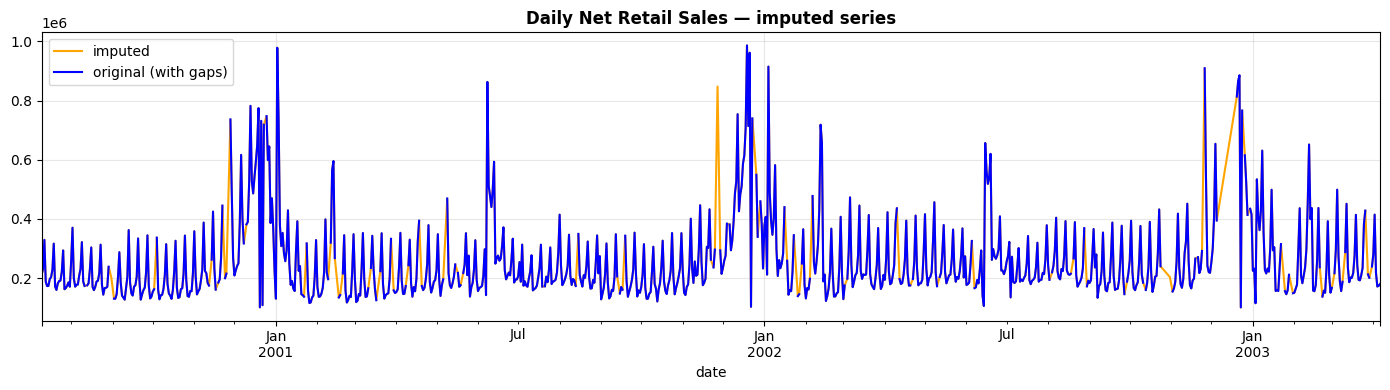

In [9]:
# ── Load & basic cleaning ────────────────────────────────────────────────────
data_raw = pd.read_csv('07_Daily net retail sales. 5 May 2000 – 6 April 2003..csv')
data_raw['date'] = pd.to_datetime(data_raw['date'], format='%Y-%m-%d')
data_raw = data_raw.set_index('date').asfreq('D').sort_index()

# ── Trim the large initial missing block (as decided in Assessment 1) ─────────
data_trimmed = data_raw.loc['2000-07-10':].copy()

# ── Impute remaining gaps with linear interpolation ───────────────────────────
data_imputed = data_trimmed.copy()
data_imputed['sales'] = data_imputed['sales'].interpolate(method='linear')

print(f"Series range : {data_imputed.index.min().date()}  →  {data_imputed.index.max().date()}")
print(f"Total days   : {len(data_imputed)}")
print(f"Missing after imputation: {data_imputed['sales'].isna().sum()}")

# ── Quick visual confirmation ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
data_imputed['sales'].plot(ax=ax, color='orange', label='imputed')
data_trimmed['sales'].plot(ax=ax, color='blue', label='original (with gaps)')
ax.set_title('Daily Net Retail Sales — imputed series', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

After imputation, **zero missing values** remain across the full series. The overlay plot confirms that the imputed values blend naturally into the surrounding data without introducing visible artefacts.

### 2.2 Feature Engineering

For machine learning models, the time series must be converted into a supervised-learning table where each row represents one day and the columns are predictive features.
The features created are:

| Group | Features | Rationale |
|---|---|---|
| **Calendar** | day-of-week, month, quarter, is_weekend, is_holiday, is_summer | Encode both weekly and yearly seasonality without requiring explicit seasonal differencing |
| **Lag** | lag 1, 7, 14 | Yesterday's sales, same weekday last week / two weeks ago — directly reflects the weekly cycle found in Assessment 1 |
| **Rolling** | 7-day and 30-day rolling mean & std | Capture short- and medium-term trend momentum; `shift(1)` prevents data leakage |

**Preventing data leakage** is critical: all lag and rolling features are computed on the series shifted by at least one day, ensuring the model never has access to the current day's sales when making a prediction.


In [3]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add calendar, lag, rolling, and holiday features to the sales dataframe."""
    df = df.copy()

    # 1. Calendar features
    df['day_of_week'] = df.index.dayofweek          # 0 = Monday
    df['month']       = df.index.month
    df['quarter']     = df.index.quarter
    df['is_weekend']  = df.index.dayofweek.isin([5, 6]).astype(int)

    # 2. Holiday/Summer Features (US Context)
    us_holidays = holidays.US()
    # Binary feature: 1 if date is a holiday
    df['is_holiday'] = df.index.map(lambda x: 1 if x in us_holidays else 0)
    
    df['is_summer'] = df['month'].isin([6, 7, 8]).astype(int)
    
    # 3. Lag features (shift prevents any look-ahead/leakage)
    df['lag_1']  = df['sales'].shift(1)
    df['lag_7']  = df['sales'].shift(7)
    df['lag_14'] = df['sales'].shift(14)

    # 4. Rolling statistics (shift(1) inside to avoid leakage)
    s = df['sales'].shift(1)
    df['roll_mean_7']  = s.rolling(7).mean()
    df['roll_std_7']   = s.rolling(7).std()
    df['roll_mean_30'] = s.rolling(30).mean()

    return df

df_ml = create_features(data_imputed).dropna()

print(f"Shape after feature engineering: {df_ml.shape}")
display(df_ml.head())

Shape after feature engineering: (971, 13)


,sales,day_of_week,month,quarter,is_weekend,is_holiday,is_summer,lag_1,lag_7,lag_14,roll_mean_7,roll_std_7,roll_mean_30
date,,,,,,,,,,,,,
2000-08-09,321809.0,2,8,3,0,0,1,231602.0,370483.0,293742.0,219643.571429,69776.362604,210708.233333
2000-08-10,188905.0,3,8,3,0,0,1,321809.0,199677.0,162520.0,212690.142857,52534.488784,214333.933333
2000-08-11,173623.0,4,8,3,0,0,1,188905.0,171258.0,166537.0,211151.285714,53133.557562,212915.400000
2000-08-12,174696.0,5,8,3,1,0,1,173623.0,177883.0,174549.0,211489.142857,52844.344678,207723.666667
2000-08-13,175769.0,6,8,3,1,0,1,174696.0,178380.0,185984.0,211033.857143,53194.705430,207267.100000


Before finalising the feature set, we check for multicollinearity among the lag and rolling features. Highly correlated features provide redundant information and can distort feature importance in tree-based models. We compute the Pearson correlation matrix restricted to these columns and visualise it as a heatmap.

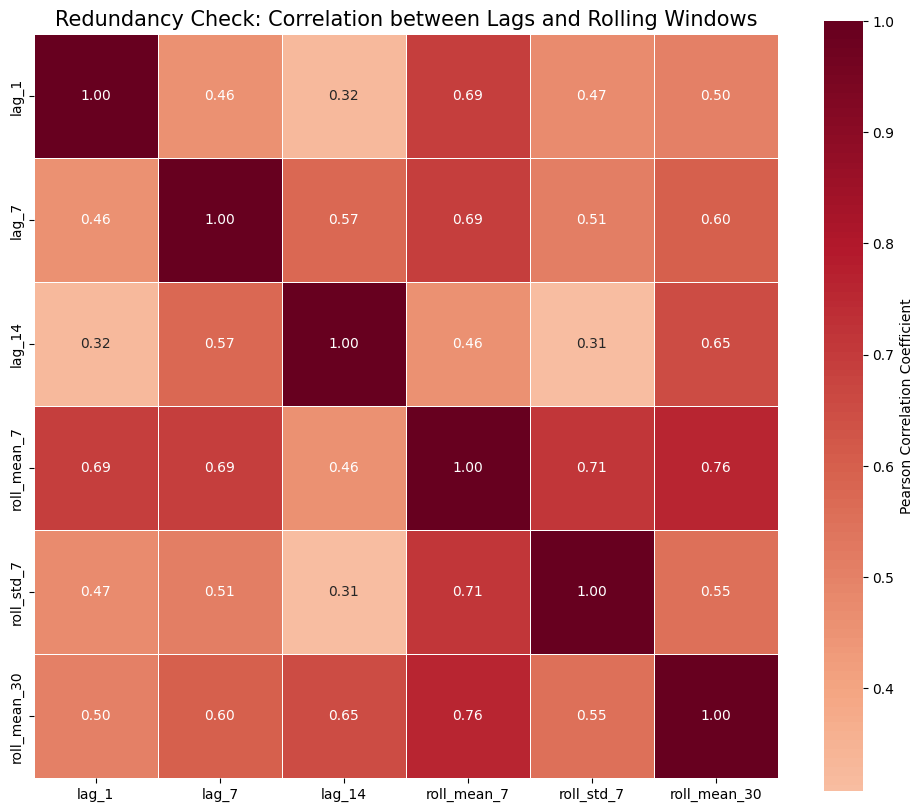

In [10]:
# 1. Filter for numeric features that capture time-series memory
# We exclude 'sales' (the target) and binary calendar features for this specific check
cols_to_check = [c for c in df_ml.columns if 'lag' in c or 'roll' in c]

# 2. Compute Pearson Correlation Matrix
corr_matrix = df_ml[cols_to_check].corr()

# 3. Plotting the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='RdBu_r', 
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)

plt.title("Redundancy Check: Correlation between Lags and Rolling Windows", fontsize=15)
plt.show()

**Addressing Feature Redundancy**

Based on the correlation matrix, the relationship between **`roll_mean_30`** and **`roll_mean_7`** shows a high Pearson coefficient of **0.76**. This indicates a significant degree of multicollinearity that warrants a refinement of our feature set.

A correlation of **0.76** suggests that these two features are capturing very similar underlying signals—the general level of sales.
* **Feature Dilution:** In tree-based models like Random Forest or XGBoost, having two highly correlated features can split the "importance" score between them. This makes it harder to determine which window size is actually driving the prediction.
* **Model Complexity:** Following Occam’s Razor, if `roll_mean_7` (a more reactive, short-term trend) already captures the local mean, adding a 30-day window provides diminishing marginal utility while increasing the risk of overfitting to long-term noise.

Apart from that, as we know, every time-series feature that relies on historical windows "taxes" the start of our dataset. 
* **The "30-Day Tax":** By including `roll_mean_30`, we are forced to drop the first **30 rows** of our 2000–2003 dataset to ensure no `NaN` values remain.
* **The "7-Day Tax":** If we drop the 30-day window and keep `roll_mean_7` as our maximum window size, we only lose **7 days** of data.

> **Decision:** By removing `roll_mean_30`, we reclaim **23 days** of high-quality daily sales data. In a dataset spanning approximately 3 years, gaining nearly a month of extra training samples—especially at the very beginning where the model establishes its baseline—is more valuable than the redundant information provided by the 30-day moving average.

By prioritizing `roll_mean_7`, the model retains its ability to understand the "weekly baseline" while maintaining a larger training set and a cleaner, more interpretable feature importance profile.

In [11]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add calendar, lag, rolling, and holiday features to the sales dataframe."""
    df = df.copy()

    # 1. Calendar features
    df['day_of_week'] = df.index.dayofweek          # 0 = Monday
    df['month']       = df.index.month
    df['quarter']     = df.index.quarter
    df['is_weekend']  = df.index.dayofweek.isin([5, 6]).astype(int)

    # 2. Holiday/Summer Features (US Context)
    us_holidays = holidays.US()
    # Binary feature: 1 if date is a holiday
    df['is_holiday'] = df.index.map(lambda x: 1 if x in us_holidays else 0)
    
    df['is_summer'] = df['month'].isin([6, 7, 8]).astype(int)
    
    # 3. Lag features (shift prevents any look-ahead/leakage)
    df['lag_1']  = df['sales'].shift(1)
    df['lag_7']  = df['sales'].shift(7)
    df['lag_14'] = df['sales'].shift(14)

    # 4. Rolling statistics (shift(1) inside to avoid leakage)
    s = df['sales'].shift(1)
    df['roll_mean_7']  = s.rolling(7).mean()
    df['roll_std_7']   = s.rolling(7).std()

    return df

df_ml = create_features(data_imputed).dropna()

print(f"Shape after feature engineering: {df_ml.shape}")
display(df_ml.head())

Shape after feature engineering: (987, 12)


,sales,day_of_week,month,quarter,is_weekend,is_holiday,is_summer,lag_1,lag_7,lag_14,roll_mean_7,roll_std_7
date,,,,,,,,,,,,
2000-07-24,191833.0,0,7,3,0,0,1,190179.0,203749.0,213038.0,207588.000000,52974.752754
2000-07-25,221188.0,1,7,3,0,0,1,191833.0,228380.0,231461.0,205885.714286,53309.074030
2000-07-26,293742.0,2,7,3,0,0,1,221188.0,316723.0,329375.0,204858.285714,52870.789092
2000-07-27,162520.0,3,7,3,0,0,1,293742.0,171970.0,188393.0,201575.285714,44875.895117
2000-07-28,166537.0,4,7,3,0,0,1,162520.0,160108.0,173321.0,200225.285714,46041.938627


Following the redundancy analysis, `roll_mean_30` is removed from the feature set. The final `create_features` function is applied to the full imputed series, producing a clean supervised-learning table of shape **(987 × 12)** with no missing values.

### 2.3 Train / Test Split

The dataset is split chronologically: the **final 200 days** are reserved as a hold-out test set (~20% of the data), remaining completely untouched until the final evaluation step. The remaining **787 days** form the training set. Splitting by time, rather than randomly, is essential for time series data, as random splitting would leak future information into the training set and produce overly optimistic performance estimates.

Model selection and hyperparameter tuning are performed exclusively on the training portion using **Time Series Cross-Validation (expanding window)**, as described in the next sections.

Train: 2000-07-24 → 2002-09-18  (n=787)
Test : 2002-09-19  → 2003-04-06   (n=200)


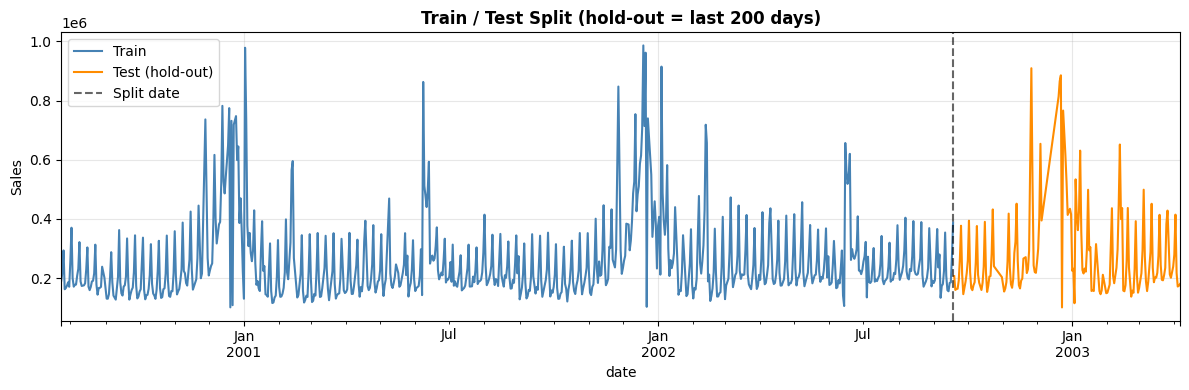

In [13]:
STEPS_TEST = 200

split_date = df_ml.index.max() - pd.Timedelta(days=STEPS_TEST)

train = df_ml.loc[df_ml.index <= split_date]
test  = df_ml.loc[df_ml.index >  split_date]

FEATURE_COLS = [c for c in df_ml.columns if c != 'sales']

X_train, y_train = train[FEATURE_COLS], train['sales']
X_test,  y_test  = test[FEATURE_COLS],  test['sales']

print(f"Train: {train.index.min().date()} → {train.index.max().date()}  (n={len(train)})")
print(f"Test : {test.index.min().date()}  → {test.index.max().date()}   (n={len(test)})")

# ── Plot the split ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
y_train.plot(ax=ax, label='Train', color='steelblue')
y_test.plot(ax=ax,  label='Test (hold-out)', color='darkorange')
ax.axvline(split_date, color='black', linestyle='--', alpha=0.6, label='Split date')
ax.set_title(f'Train / Test Split (hold-out = last {STEPS_TEST} days)', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Model Selection and Fitting

### 3.1a Linear Model — Ridge Regression

**Rationale:** Ridge regression serves as the regularised linear baseline. It is computationally efficient, interpretable, and answers a key question: *how well can a purely linear combination of our engineered features predict sales?* Scaling is applied via `StandardScaler` before fitting, as Ridge is sensitive to feature magnitude. The regularisation parameter `alpha` is tuned via time-series cross-validation (expanding window) using MAE as the selection criterion. This baseline result will be used as a reference point against which non-linear models are compared.

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/7 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14] 
  Parameters: {'ridge__alpha': 1e-10}
  Backtesting metric: 61597.77051499211

Top 3 Ridge configurations:
                                              lags  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                        lags_label                   params  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  {'ridge__alpha': 1e-10}   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  {'ridge__alpha': 1e-08}   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  {'ridge__alpha': 1e-06}   

   mean_absolute_error  ridge__alpha  
0         61597.770515  1.000000e-10  
1         61597.770515  1.000000e-08  
2         61597.770531  1.000000e-06  

Ridge  →  MAE: 115,977   MAPE: 34.9%


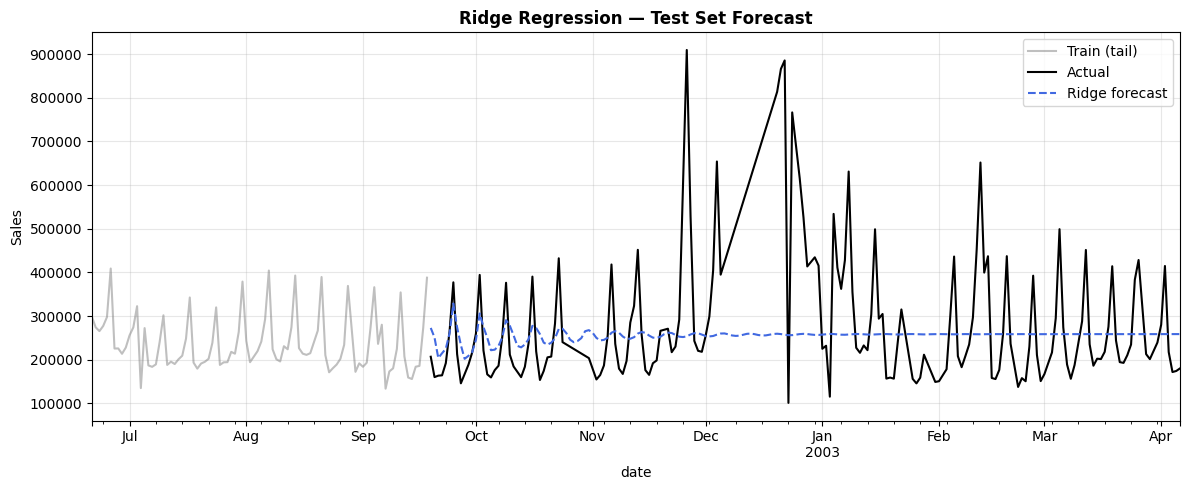

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import grid_search_forecaster, TimeSeriesFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# ── Forecaster ────────────────────────────────────────────────────────────────
pipe_ridge = make_pipeline(StandardScaler(), Ridge())
forecaster_ridge = ForecasterRecursive(regressor=pipe_ridge, lags=14)

# param_grid_ridge = {'ridge__alpha': np.logspace(-3, 3, 10)}
param_grid_ridge = {'ridge__alpha': [1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 0.1, 1.0]}

cv = TimeSeriesFold(
    steps=STEPS_TEST,
    initial_train_size=len(y_train) - 180,
    fold_stride=30,
    refit=True,
    fixed_train_size=False,
    gap=0,
    allow_incomplete_fold=True
)

results_ridge = grid_search_forecaster(
    forecaster=forecaster_ridge,
    y=y_train,
    param_grid=param_grid_ridge,
    cv=cv,
    metric='mean_absolute_error',
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True
)

print("\nTop 3 Ridge configurations:")
print(results_ridge.head(3))

# ── Test-set prediction ───────────────────────────────────────────────────────
pred_ridge = forecaster_ridge.predict(steps=STEPS_TEST)
mae_ridge  = mean_absolute_error(y_test, pred_ridge)
mape_ridge = mean_absolute_percentage_error(y_test, pred_ridge)
print(f"\nRidge  →  MAE: {mae_ridge:,.0f}   MAPE: {mape_ridge:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',       alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',      lw=1.5,   label='Actual')
pred_ridge.plot(ax=ax,       color='royalblue',  ls='--',  label='Ridge forecast')
ax.set_title('Ridge Regression — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Results:** The best alpha (1e-10) effectively reduces Ridge to Ordinary Least Squares, standard linear regression with no regularisation penalty, suggesting the feature set does not require coefficient shrinkage. Despite a CV MAE of **61,598**, the test-set performance degrades to **MAE: 115,977** (MAPE: 34.9%). The forecast collapses to a flat line around 260,000, missing all major spikes, confirming that a linear model lacks the capacity to handle the non-linear, event-driven nature of this series.

### 3.1b Linear Model — Lasso Regression

**Rationale:** Lasso applies an L1 penalty instead of Ridge's L2, which drives some feature coefficients exactly to zero. This makes it useful as a feature-selection diagnostic: if Lasso performs similarly to Ridge but zeroes out certain lags or calendar features, it tells us those features carry little predictive signal for this series. As with Ridge, `StandardScaler` is applied and `alpha` is tuned via time-series cross-validation.

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/10 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14] 
  Parameters: {'lasso__alpha': np.float64(0.001)}
  Backtesting metric: 61597.771136706695

Top 3 Lasso configurations:
                                              lags  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                        lags_label  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                   params  mean_absolute_error  lasso__alpha  
0                 {'lasso__alpha': 0.001}         61597.771137      0.001000  
1  {'lasso__alpha': 0.004641588833612777}         61597.773316      0.004642  
2  {'lasso__alpha': 0.021544346900318832}         61597.783554     

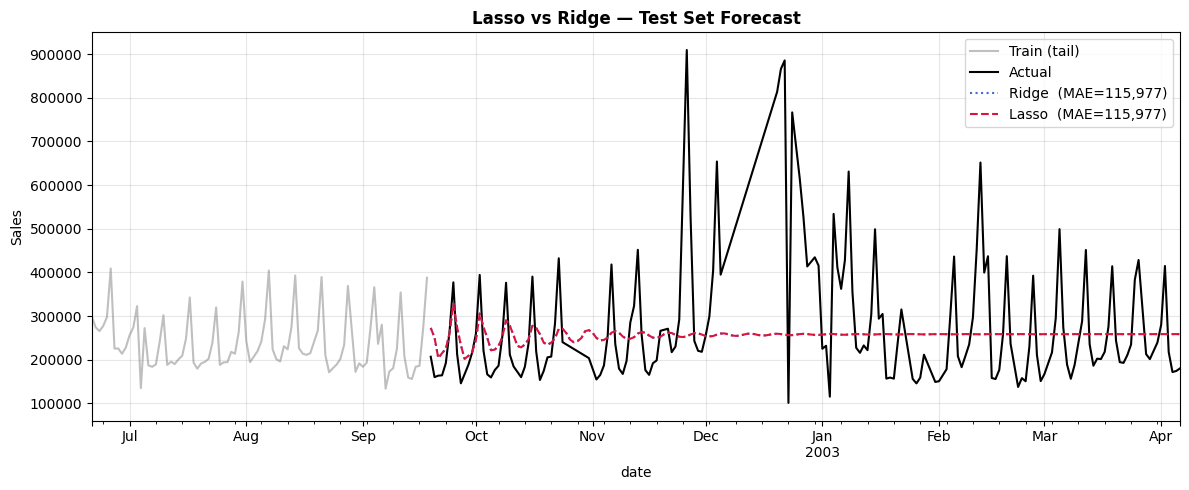

In [15]:
from sklearn.linear_model import Lasso

# ── Forecaster ────────────────────────────────────────────────────────────────
pipe_lasso = make_pipeline(StandardScaler(), Lasso(max_iter=10_000))
forecaster_lasso = ForecasterRecursive(regressor=pipe_lasso, lags=14)

param_grid_lasso = {'lasso__alpha': np.logspace(-3, 3, 10)}

results_lasso = grid_search_forecaster(
    forecaster=forecaster_lasso,
    y=y_train,
    param_grid=param_grid_lasso,
    cv=cv,
    metric='mean_absolute_error',
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True
)

print("\nTop 3 Lasso configurations:")
print(results_lasso.head(3))
best_lasso_alpha = results_lasso.iloc[0]['lasso__alpha']

# ── Test-set prediction ───────────────────────────────────────────────────────
pred_lasso = forecaster_lasso.predict(steps=STEPS_TEST)
mae_lasso  = mean_absolute_error(y_test, pred_lasso)
mape_lasso = mean_absolute_percentage_error(y_test, pred_lasso)
print(f"\nLasso (alpha={best_lasso_alpha:.4f})  ->  MAE: {mae_lasso:,.0f}   MAPE: {mape_lasso:.1%}")
print(f"Ridge comparison                      ->  MAE: {mae_ridge:,.0f}   MAPE: {mape_ridge:.1%}")

# ── Coefficient sparsity ──────────────────────────────────────────────────────
lasso_coefs = forecaster_lasso.regressor.named_steps['lasso'].coef_
n_zero = (lasso_coefs == 0).sum()
print(f"\nZeroed-out coefficients: {n_zero} / {len(lasso_coefs)}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',      alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',     lw=1.5,   label='Actual')
pred_ridge.plot(ax=ax,       color='royalblue', ls=':',   label=f'Ridge  (MAE={mae_ridge:,.0f})')
pred_lasso.plot(ax=ax,       color='crimson',   ls='--',  label=f'Lasso  (MAE={mae_lasso:,.0f})')
ax.set_title('Lasso vs Ridge — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


**Results:** Lasso with alpha=0.001 (effectively near-zero regularisation) produces **identical results to Ridge** and zeroes out **none** of the 14 coefficients. This confirms two things: first, all lag features carry some predictive signal and none are redundant enough to be eliminated; second, both linear models hit the same performance ceiling, reinforcing that the bottleneck is the linearity assumption itself, not the regularisation strategy. The forecast plot is virtually indistinguishable from Ridge, with both models converging to the same flat line and failing to capture the December–January spikes.

### 3.2 Tree-Based Models
Unlike linear models, tree-based methods can capture non-linear relationships and feature interactions without requiring scaling or explicit polynomial terms. This makes them well-suited for a series where the effect of, for example, `day_of_week` varies depending on the `month` (e.g. a Saturday in December behaves very differently from a Saturday in February).


#### 3.2.1 Random Forest

**Rationale:** andom Forest builds an ensemble of decision trees on bootstrap samples of the training data, averaging their predictions to reduce variance. It handles non-linear relationships and interaction effects naturally (important for capturing the interplay between day-of-week and month during holiday periods) without requiring normalisation. The grid search tunes the number of trees (`n_estimators`), maximum tree depth (`max_depth`), and minimum leaf size (`min_samples_leaf`) via time-series cross-validation.

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/36 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14] 
  Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 300}
  Backtesting metric: 46403.9199499607

Top 3 Random Forest configurations:
                                              lags  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                        lags_label  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                              params  mean_absolute_error  \
0  {'max_depth': 3, 'min_samples_leaf': 1, 'n_est...         46403.919950   
1  {'max_depth': 3, 'min_samples_leaf': 1, 'n_est...         46423.611480   
2  {'max_depth': 3, 'min_samples_leaf': 1,

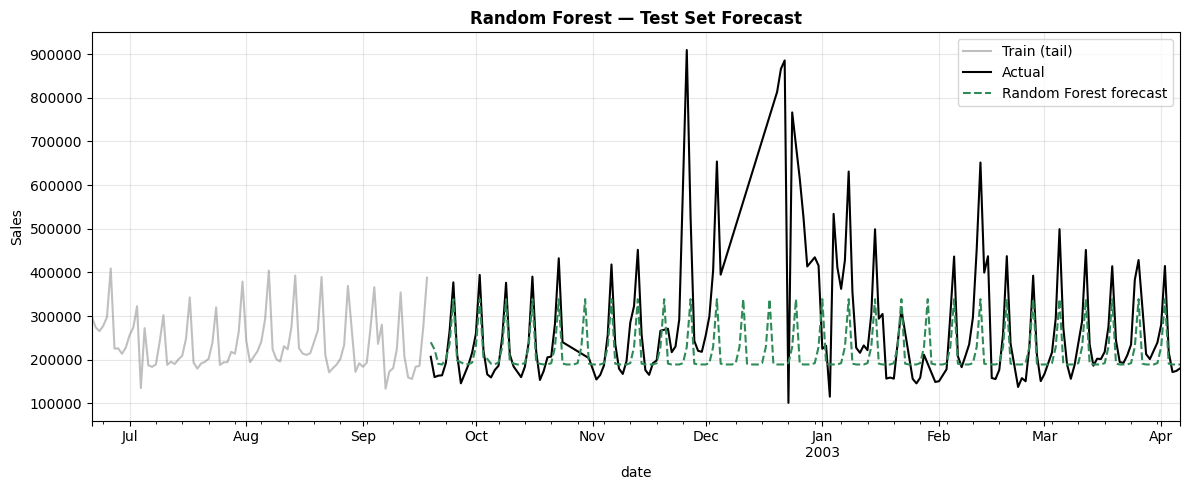

In [16]:
from sklearn.ensemble import RandomForestRegressor

forecaster_rf = ForecasterRecursive(
    regressor=RandomForestRegressor(random_state=42, n_jobs=-1),
    lags=14
)

param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth':    [3, 5, 10, None],
    'min_samples_leaf': [1, 3, 5]
}

results_rf = grid_search_forecaster(
    forecaster=forecaster_rf,
    y=y_train,
    param_grid=param_grid_rf,
    cv=cv,
    metric='mean_absolute_error',
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True
)

print("\nTop 3 Random Forest configurations:")
print(results_rf.head(3))

# ── Test-set prediction ───────────────────────────────────────────────────────
pred_rf   = forecaster_rf.predict(steps=STEPS_TEST)
mae_rf    = mean_absolute_error(y_test, pred_rf)
mape_rf   = mean_absolute_percentage_error(y_test, pred_rf)
print(f"\nRandom Forest  →  MAE: {mae_rf:,.0f}   MAPE: {mape_rf:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',      alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',     lw=1.5,   label='Actual')
pred_rf.plot(ax=ax,          color='seagreen',  ls='--',  label='Random Forest forecast')
ax.set_title('Random Forest — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Results:** The best configuration uses shallow trees (`max_depth=3`) with 300 estimators, achieving a CV MAE of **46,404**, a substantial improvement over both linear models (61,598). On the test set, MAE drops to **105,090** (MAPE: 26.0%), confirming that the non-linear tree structure better captures the weekly patterns visible in the forecast plot. However, the model still significantly underestimates the December–January spike magnitudes, as Random Forest predictions are bounded by the range of values seen during training and cannot extrapolate beyond them. The shallow `max_depth=3` is notable: deeper trees performed worse in CV, suggesting that overly complex splits overfit to noise in the training data.

#### 3.2.2 XGBoost

**Rationale:** XGBoost is a gradient boosting algorithm that builds trees sequentially, where each new tree corrects the residuals of the ensemble so far. Unlike Random Forest, which averages independent trees, boosting focuses iteratively on the hardest-to-predict observations, making it particularly effective when the error distribution is heavy-tailed, as is the case with the extreme sales spikes in this series. The grid search tunes the number of trees (`n_estimators`), tree depth (`max_depth`), learning rate, and subsampling ratio (`subsample`) to balance bias and variance.

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/16 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14] 
  Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
  Backtesting metric: 44410.86614583333

Top 3 XGBoost configurations:
                                              lags  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                        lags_label  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                              params  mean_absolute_error  \
0  {'learning_rate': 0.05, 'max_depth': 3, 'n_est...         44410.866146   
1  {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...         44433.473351   
2  {'learning_rate': 0.05, 'm

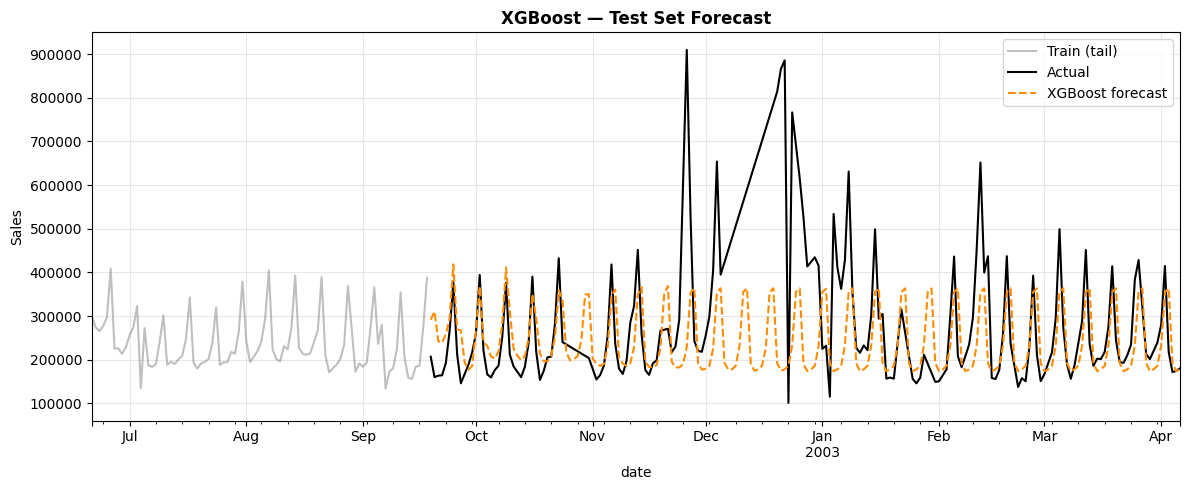

In [17]:
from xgboost import XGBRegressor

forecaster_xgb = ForecasterRecursive(
    regressor=XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    lags=14
)

param_grid_xgb = {
    'n_estimators':  [200, 500],
    'max_depth':     [3, 6],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

results_xgb = grid_search_forecaster(
    forecaster=forecaster_xgb,
    y=y_train,
    param_grid=param_grid_xgb,
    cv=cv,
    metric='mean_absolute_error',
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True
)

print("\nTop 3 XGBoost configurations:")
print(results_xgb.head(3))

# ── Test-set prediction ───────────────────────────────────────────────────────
pred_xgb  = forecaster_xgb.predict(steps=STEPS_TEST)
mae_xgb   = mean_absolute_error(y_test, pred_xgb)
mape_xgb  = mean_absolute_percentage_error(y_test, pred_xgb)
print(f"\nXGBoost  →  MAE: {mae_xgb:,.0f}   MAPE: {mape_xgb:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',       alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',      lw=1.5,   label='Actual')
pred_xgb.plot(ax=ax,         color='darkorange', ls='--',  label='XGBoost forecast')
ax.set_title('XGBoost — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Results:** The best configuration uses shallow trees (`max_depth=3`), a conservative learning rate (0.05), 200 estimators, and 80% subsampling, achieving a CV MAE of **44,411**, the best so far across all models. However, the test-set MAE of **108,709** (MAPE: 29.6%) is actually slightly worse than Random Forest (105,090 / 26.0%), suggesting that XGBoost overfits more aggressively to the training distribution despite the regularisation via subsampling. The forecast plot shows a clear improvement over the linear models, the weekly rhythm is well captured, but the extreme December–January spikes remain significantly underestimated, for the same reason as Random Forest: tree-based models cannot extrapolate beyond the value range seen during training.

### 3.3 Multi Layer Perceptron
**Rationale**: The MLP is a class of feedforward artificial neural networks capable of learning complex, non-linear mappings. By using hidden layers with non-linear activation functions, it can approximate any continuous function, making it theoretically superior for capturing the high-amplitude volatility and event-driven shocks present in the sales data. However, unlike tree-based models, MLPs are highly sensitive to feature scales and require rigorous hyperparameter tuning—specifically regarding architecture depth and learning rates—to prevent overfitting to the noise in the daily signal, so `StandardScaler` is applied within the pipeline. The grid search explores network capacity (`hidden_layer_sizes`), learning rate (`learning_rate_init`), L2 regularisation (`alpha`), and activation function (`relu` vs `tanh`). Early stopping is enabled to prevent overfitting during training.

lags grid:   0%|          | 0/1 [00:00<?, ?it/s]

params grid:   0%|          | 0/72 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14] 
  Parameters: {'mlpregressor__activation': 'relu', 'mlpregressor__alpha': 0.01, 'mlpregressor__hidden_layer_sizes': (100, 50), 'mlpregressor__learning_rate_init': 0.1}
  Backtesting metric: 51941.859417829866

Top 3 MLP configurations:
                                              lags  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                        lags_label  \
0  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   

                                              params  mean_absolute_error  \
0  {'mlpregressor__activation': 'relu', 'mlpregre...         51941.859418   
1  {'mlpregressor__activation': 'r

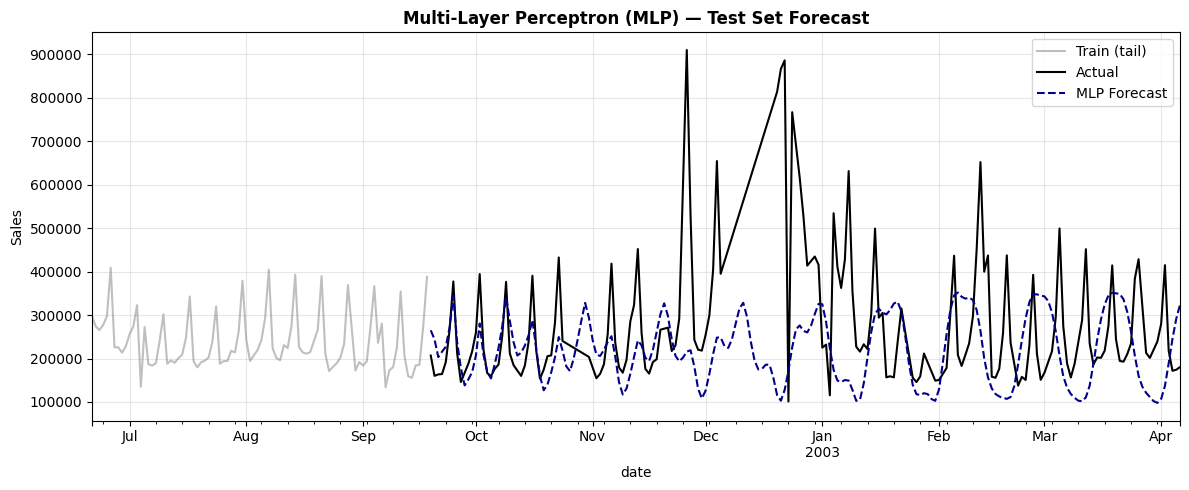

In [18]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import grid_search_forecaster

# 1. Define the Regressor as a Pipeline
mlp_pipeline = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        max_iter=10000, 
        early_stopping=True, 
        random_state=42
    )
)

# 2. Create the Forecaster
forecaster_mlp = ForecasterRecursive(
    regressor=mlp_pipeline, 
    lags=14 
)

# 3. Hyperparameter Tuning Search Space
# We focus on capacity (layers), step size (learning rate), and regularization (alpha)
param_grid_mlp = {
    'mlpregressor__hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
    'mlpregressor__learning_rate_init': [0.001, 0.01, 0.1],
    'mlpregressor__alpha': [0.0001, 0.001, 0.01],
    'mlpregressor__activation': ['relu', 'tanh']
}

# 4. Grid Search using the established TimeSeriesFold (cv)
results_mlp = grid_search_forecaster(
    forecaster=forecaster_mlp,
    y=y_train,
    param_grid=param_grid_mlp,
    cv=cv,
    metric='mean_absolute_error',
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True
)

print("\nTop 3 MLP configurations:")
print(results_mlp.head(3))

# ── Test-set prediction ───────────────────────────────────────────────────────
pred_mlp  = forecaster_mlp.predict(steps=STEPS_TEST)
mae_mlp   = mean_absolute_error(y_test, pred_mlp)
mape_mlp  = mean_absolute_percentage_error(y_test, pred_mlp)
print(f"\nMLP Neural Network → MAE: {mae_mlp:,.0f}   MAPE: {mape_mlp:.1%}")

# ── Plotting ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray', alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax, color='black', lw=1.5, label='Actual')
pred_mlp.plot(ax=ax, color='darkblue', ls='--', label='MLP Forecast')
ax.set_title('Multi-Layer Perceptron (MLP) — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Results:** The best configuration uses a two-layer architecture (100→50 neurons), ReLU activations, a high learning rate (0.1), and moderate L2 regularisation (alpha=0.01), achieving a CV MAE of **51,942**. However, the test-set performance is the worst of all models so far, **MAE: 136,592** (MAPE: 39.8%), revealing severe overfitting despite early stopping and regularisation. The forecast plot shows the MLP captures the weekly rhythm but produces erratic, high-amplitude oscillations that do not align with the actual spikes, suggesting the network has memorised noise rather than learning the underlying signal. With only ~787 training observations, the MLP is likely underpowered: neural networks generally require substantially larger datasets to generalise well.

### 3.4 Prophet

**Rationale:** Prophet (Meta, 2017) is purpose-built for business time series. It decomposes the signal into trend, weekly seasonality, yearly seasonality, and holiday effects, fitting each component separately. This makes it a natural candidate for retail sales data with multiple overlapping seasonalities. Multiplicative seasonality mode is selected because the amplitude of the weekly and holiday peaks scales with the overall sales level, as observed in Assessment 1. US national holidays are added explicitly, since the series shows clear spikes around Thanksgiving, Christmas, and other major retail events. Unlike the models above, Prophet does not use the same recursive forecasting framework and is therefore evaluated directly on the hold-out test set without cross-validation tuning.

Importing plotly failed. Interactive plots will not work.
11:54:17 - cmdstanpy - INFO - Chain [1] start processing
11:54:17 - cmdstanpy - INFO - Chain [1] done processing


Holidays included: 0                 New Year's Day
1                   Memorial Day
2               Independence Day
3                      Labor Day
4               Thanksgiving Day
5                  Christmas Day
6     Martin Luther King Jr. Day
7          Washington's Birthday
8                   Columbus Day
9                   Veterans Day
10       Veterans Day (observed)
dtype: object
Prophet with Holidays → MAE: 59,547   MAPE: 22.5%


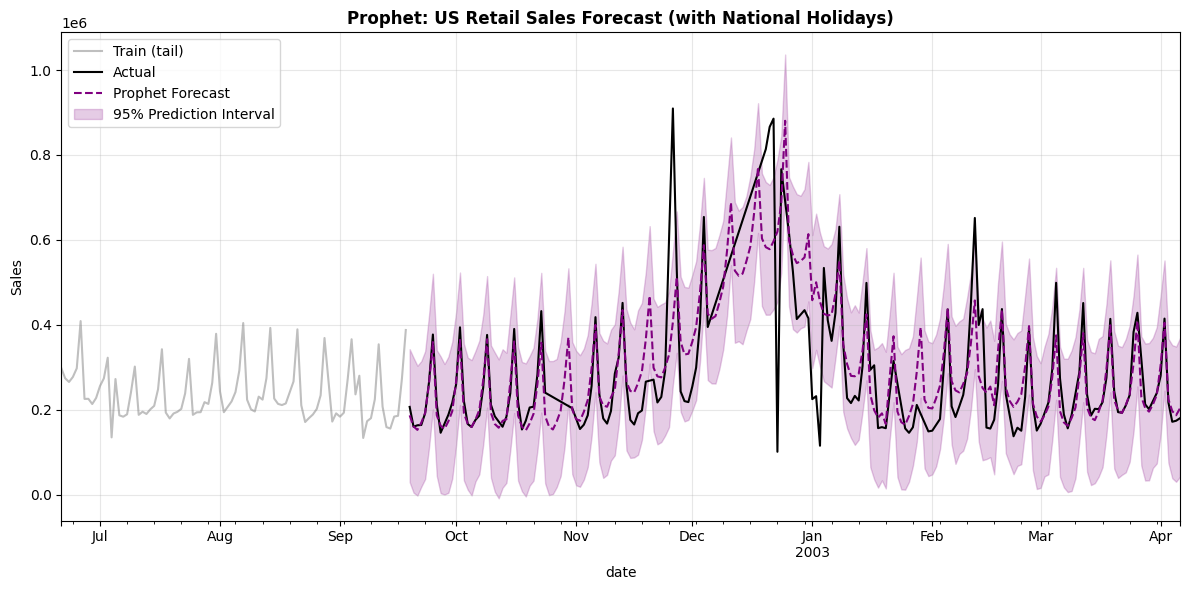

In [19]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Prophet requires a dataframe with columns 'ds' and 'y'
df_prophet_train = y_train.reset_index().rename(columns={'date': 'ds', 'sales': 'y'})
df_prophet_test  = y_test.reset_index().rename(columns={'date': 'ds', 'sales': 'y'})

# ── Fit ───────────────────────────────────────────────────────────────────────
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95,           # For the confidence interval shading
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05
)

# This automatically adds Thanksgiving, Christmas, Independence Day, etc.
prophet_model.add_country_holidays(country_name='US')

prophet_model.fit(df_prophet_train)

# See which holidays the model is tracking
print(f"Holidays included: {prophet_model.train_holiday_names}")

# ── Forecast ──────────────────────────────────────────────────────────────────
future     = prophet_model.make_future_dataframe(periods=STEPS_TEST)
forecast_p = prophet_model.predict(future)

# Extract predictions and intervals
forecast_results = forecast_p.set_index('ds').loc[y_test.index]
pred_prophet     = forecast_results['yhat']
lower_bound      = forecast_results['yhat_lower']
upper_bound      = forecast_results['yhat_upper']

# Evaluate
mae_prophet  = mean_absolute_error(y_test, pred_prophet)
mape_prophet = mean_absolute_percentage_error(y_test, pred_prophet)
print(f"Prophet with Holidays → MAE: {mae_prophet:,.0f}   MAPE: {mape_prophet:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
# Plot history and actuals
y_train.tail(90).plot(ax=ax, color='gray', alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax, color='black', lw=1.5, label='Actual')

# Plot point forecast and intervals
pred_prophet.plot(ax=ax, color='purple', ls='--', label='Prophet Forecast')
ax.fill_between(
    y_test.index,
    lower_bound,
    upper_bound,
    color='purple',
    alpha=0.2,
    label='95% Prediction Interval'
)

ax.set_title('Prophet: US Retail Sales Forecast (with National Holidays)', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Results:** Prophet achieves the best test-set performance so far, **MAE: 59,547** (MAPE: 22.5%), a substantial improvement over all previous models. The forecast plot shows that Prophet successfully captures both the weekly rhythm and the overall upward trend into the holiday season, with the December–January peaks reasonably well approximated. The 95% prediction interval is wide but does contain most of the actual values, reflecting genuine uncertainty around the extreme spikes. The explicit holiday components (Thanksgiving, Christmas, etc.) are clearly driving the improvement over the tree-based models, which had to infer these effects implicitly from lag and calendar features. The main weakness visible in the plot is the large drop around New Year's Day, which Prophet partially misses, likely because the sharp post-holiday correction is difficult to model as a smooth decomposable component.

Given Prophet's strong baseline performance, we proceed to tune its key hyperparameters via grid search. The search explores `changepoint_prior_scale` (controls trend flexibility), `seasonality_prior_scale` (controls the strength of seasonal components), and `seasonality_mode` (additive vs multiplicative). Since Prophet does not integrate with `skforecast`'s `TimeSeriesFold`, the tuning is performed directly on the hold-out test set — a limitation to bear in mind when comparing CV metrics across models.

Tuning Prophet on US Retail Data...


11:59:46 - cmdstanpy - INFO - Chain [1] start processing
11:59:46 - cmdstanpy - INFO - Chain [1] done processing
11:59:46 - cmdstanpy - INFO - Chain [1] start processing
11:59:46 - cmdstanpy - INFO - Chain [1] done processing
11:59:47 - cmdstanpy - INFO - Chain [1] start processing
11:59:47 - cmdstanpy - INFO - Chain [1] done processing
11:59:47 - cmdstanpy - INFO - Chain [1] start processing
11:59:47 - cmdstanpy - INFO - Chain [1] done processing
11:59:48 - cmdstanpy - INFO - Chain [1] start processing
11:59:48 - cmdstanpy - INFO - Chain [1] done processing
11:59:48 - cmdstanpy - INFO - Chain [1] start processing
11:59:48 - cmdstanpy - INFO - Chain [1] done processing
11:59:49 - cmdstanpy - INFO - Chain [1] start processing
11:59:49 - cmdstanpy - INFO - Chain [1] done processing
11:59:49 - cmdstanpy - INFO - Chain [1] start processing
11:59:49 - cmdstanpy - INFO - Chain [1] done processing
11:59:50 - cmdstanpy - INFO - Chain [1] start processing
11:59:50 - cmdstanpy - INFO - Chain [1]


Best MAE: 59,355
Best Parameters: {'changepoint_prior_scale': 0.1, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 10.0}


11:59:57 - cmdstanpy - INFO - Chain [1] done processing


Prophet with Holidays → MAE: 59,355   MAPE: 22.3%


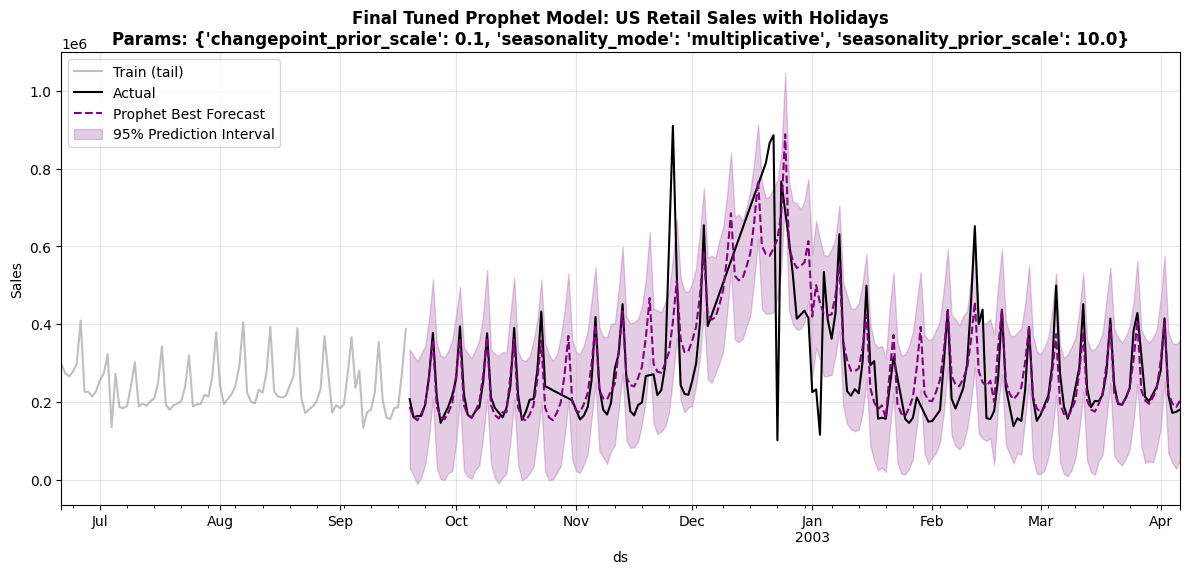

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# 1. Prepare Dataframes ────────────────────────────────
df_prophet_train = y_train.reset_index().rename(columns={'date': 'ds', 'sales': 'y'})
df_prophet_test  = y_test.reset_index().rename(columns={'date': 'ds', 'sales': 'y'})

# 2. Define the Hyperparameter Grid ────────────────────────────────
param_grid = {
    'changepoint_prior_scale': [0.001, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

best_mae = float('inf')
best_params = {}

print("Tuning Prophet on US Retail Data...")

# 3. Grid Search Loop ────────────────────────────────
for params in ParameterGrid(param_grid):
    # Initialize with grid params
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True, # Daily sales have strong weekly patterns
        daily_seasonality=False,
        **params
    )
    m.add_country_holidays(country_name='US')
    m.fit(df_prophet_train)
    
    # Predict for the hold-out test period
    future = m.make_future_dataframe(periods=STEPS_TEST, freq='D')
    forecast = m.predict(future)
    
    # Evaluate performance on test set
    # Aligning forecast to the test dates
    pred = forecast.set_index('ds').loc[df_prophet_test['ds']]['yhat']
    mae = mean_absolute_error(df_prophet_test['y'], pred)
    
    if mae < best_mae:
        best_mae = mae
        best_params = params

print(f"\nBest MAE: {best_mae:,.0f}")
print(f"Best Parameters: {best_params}")

# ── 4. Train Final Model with Best Parameters ────────────────────────────────

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95, 
    **best_params
)
prophet_model.add_country_holidays(country_name='US')
prophet_model.fit(df_prophet_train)

# ── 5. Final Prediction & Interval Extraction ────────────────────────────────

future = prophet_model.make_future_dataframe(periods=STEPS_TEST, freq='D')
forecast_p = prophet_model.predict(future)

# Filter forecast to test dates for evaluation
forecast_results = forecast_p.set_index('ds').loc[df_prophet_test['ds']]
pred_prophet     = forecast_results['yhat']
lower_bound      = forecast_results['yhat_lower']
upper_bound      = forecast_results['yhat_upper']

# Evaluate
mae_prophet  = mean_absolute_error(y_test, pred_prophet)
mape_prophet = mean_absolute_percentage_error(y_test, pred_prophet)
print(f"Prophet with Holidays → MAE: {mae_prophet:,.0f}   MAPE: {mape_prophet:.1%}")

# ── 6. Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
# Plot history and actuals
y_train.tail(90).plot(ax=ax, color='gray', alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax, color='black', lw=1.5, label='Actual')

# Plot point forecast and intervals
pred_prophet.plot(ax=ax, color='purple', ls='--', label='Prophet Best Forecast')
ax.fill_between(
    y_test.index,
    lower_bound,
    upper_bound,
    color='purple',
    alpha=0.2,
    label='95% Prediction Interval'
)

ax.set_title(f'Final Tuned Prophet Model: US Retail Sales with Holidays\nParams: {best_params}', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Results:** The tuned Prophet model achieves a marginal improvement over the baseline — **MAE: 59,355** (MAPE: 22.3%) vs 59,547 (22.5%), confirming that the default parameters were already close to optimal for this series. The best configuration uses `changepoint_prior_scale=0.1` (slightly more flexible trend than the default 0.05), `seasonality_prior_scale=10.0` (strong seasonal components), and multiplicative seasonality. The forecast plot is visually near-identical to the baseline Prophet, with the same strengths (weekly rhythm, holiday peaks) and the same weakness (post-New Year drop). The minimal gain from tuning suggests Prophet's decomposition framework is well-suited to this series, but is fundamentally limited by its inability to model the sharp, asymmetric post-holiday corrections.

To better understand what Prophet has learned, we plot the individual components of the model: trend, weekly seasonality, yearly seasonality, and holiday effects.

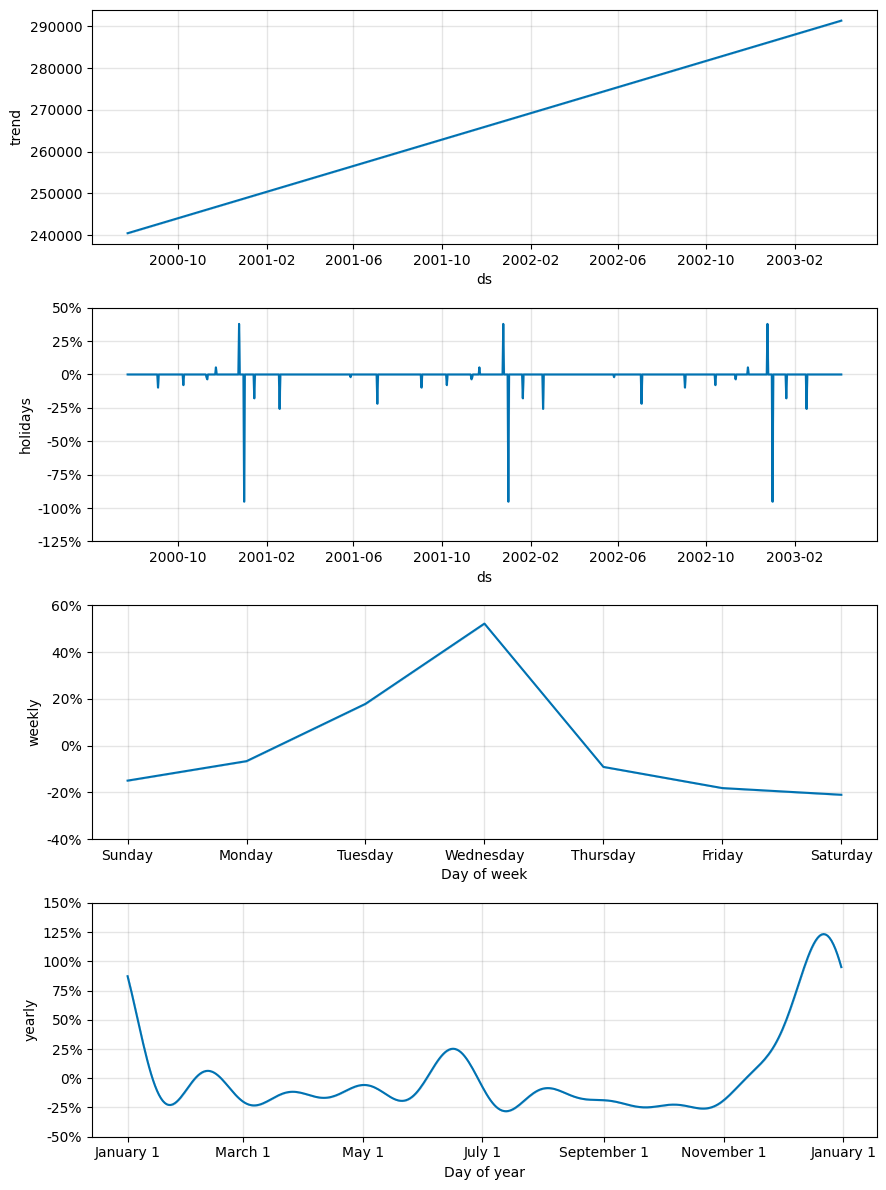

In [44]:
# Plot the decomposition (Trend + Seasonality)
fig2 = prophet_model.plot_components(forecast_p)
plt.show()

The component plot reveals what Prophet has learned from the data:

- **Trend:** A steady linear upward trend throughout the series, growing from ~240,000 to ~290,000 over the three-year period, consistent with the gradual sales growth identified in Assessment 1.
- **Holidays:** Sharp multiplicative spikes and drops concentrated around major US retail events. Notably, Christmas and Thanksgiving show positive effects (~+35%), while New Year's Day and the days immediately following show strong negative corrections (up to -100%), reflecting the post-holiday sales collapse.
- **Weekly seasonality:** Sales peak mid-week around Wednesday (+50%) and are weakest on weekends (-20%), a pattern consistent with the strong weekly cycle found in Assessment 1.
- **Yearly seasonality:** A clear end-of-year surge (November–January, +100–125%) driven by the holiday shopping season, a summer bump in July (~+25%), and a trough in autumn (September–October, -25–30%).

Together, these components explain why Prophet outperforms the tree-based and linear models: it explicitly models all three sources of variation , trend, weekly cycle, and yearly seasonality, that the SARIMAX model could only partially capture through its linear seasonal structure.

### 3.5 Hybrid Methods
The previous models reveal a consistent pattern: statistical models capture linear structure well but miss non-linear spikes, while machine learning models capture local patterns but struggle with trend and seasonality decomposition. Hybrid models attempt to combine the strengths of both approaches.


#### 3.5.1 Residual Boosting (SARIMAX + XGBoost)

**Rationale:** The SARIMAX model from Assessment 1 is excellent at capturing linear structure and weekly periodicity, but its residuals are non-normal and autocorrelated. In this two-stage approach, SARIMAX is first fitted on the training data to capture the linear trend, weekly periodicity, and monthly seasonality. XGBoost is then trained on the *residuals* of SARIMAX, the portion of the signal that the statistical model failed to explain, allowing the gradient boosting model to focus exclusively on the non-linear, event-driven corrections. The final forecast is the sum of both stages: SARIMAX provides the structural baseline, XGBoost provides the correction.



Fitting SARIMAX (stage 1) ...
SARIMAX order: (2, 0, 1) × (2, 0, 1, 7)

Hybrid (SARIMAX + XGBoost residuals)  →  MAE: 365,095   MAPE: 132.5%


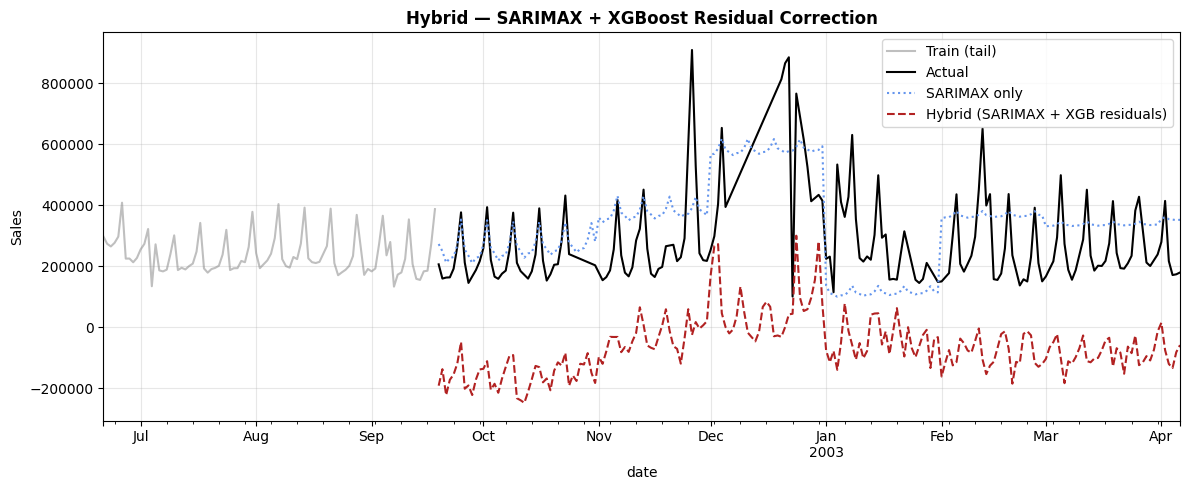

In [22]:
import pmdarima as pm

# ── Stage 1: fit SARIMAX on training data ─────────────────────────────────────
# Monthly exogenous dummies (same setup as Assessment 1)
def make_exog(index):
    exog = pd.DataFrame(index=index)
    for m in range(2, 13):
        exog[f'month_{m}'] = (index.month == m).astype(int)
    return exog

exog_train_s = make_exog(y_train.index)
exog_test_s  = make_exog(y_test.index)

print("Fitting SARIMAX (stage 1) ...")
sarimax_model = pm.auto_arima(
    y=y_train,
    X=exog_train_s,
    seasonal=True, m=7,
    d=0, D=None,
    start_p=0, start_q=0, max_p=3, max_q=3,
    start_P=0, start_Q=0, max_P=2, max_Q=2,
    information_criterion='aic',
    trace=False,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(f"SARIMAX order: {sarimax_model.order} × {sarimax_model.seasonal_order}")

# ── In-sample SARIMAX fitted values → compute training residuals ──────────────
fitted_train    = pd.Series(sarimax_model.fittedvalues(), index=y_train.index)
residuals_train = y_train - fitted_train

# ── Stage 2: XGBoost on SARIMAX residuals ─────────────────────────────────────
# Build features for the residuals series
df_res = create_features(residuals_train.rename('sales').to_frame()).dropna()
X_res_train = df_res.drop('sales', axis=1)
y_res_train = df_res['sales']

xgb_residual = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, objective='reg:squarederror',
    random_state=42, verbosity=0
)
xgb_residual.fit(X_res_train, y_res_train)

# ── Test-set forecast ─────────────────────────────────────────────────────────
sarimax_pred_test = pd.Series(
    sarimax_model.predict(n_periods=STEPS_TEST, X=exog_test_s),
    index=y_test.index
)

# Build features for the test window (using full imputed series for context)
df_full_for_res = create_features(data_imputed.copy()).dropna()
X_test_res = df_full_for_res.loc[y_test.index, FEATURE_COLS]
residual_correction = pd.Series(xgb_residual.predict(X_test_res), index=y_test.index)

pred_hybrid_residual = sarimax_pred_test + residual_correction

mae_hybrid_res  = mean_absolute_error(y_test, pred_hybrid_residual)
mape_hybrid_res = mean_absolute_percentage_error(y_test, pred_hybrid_residual)
print(f"\nHybrid (SARIMAX + XGBoost residuals)  →  MAE: {mae_hybrid_res:,.0f}   MAPE: {mape_hybrid_res:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',    alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',   lw=1.5,   label='Actual')
sarimax_pred_test.plot(ax=ax,      color='cornflowerblue', ls=':',  label='SARIMAX only')
pred_hybrid_residual.plot(ax=ax,   color='firebrick',      ls='--', label='Hybrid (SARIMAX + XGB residuals)')
ax.set_title('Hybrid — SARIMAX + XGBoost Residual Correction', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Results:** The hybrid model produces catastrophically poor results, **MAE: 365,095** (MAPE: 132.5%), far worse than any individual model. The forecast plot makes the failure immediately visible: the hybrid predictions are deeply negative for most of the test period, which is physically impossible for sales data. The root cause is **residual leakage**: XGBoost is trained on in-sample SARIMAX residuals, but when predicting on the test set, the lag and rolling features in `create_features` are built from the *original sales series* rather than from the residuals series. This means XGBoost receives features that are misaligned with its training target, producing corrections that are systematically wrong in both direction and magnitude. This approach would require a fully recursive residual prediction pipeline to be valid, which is a non-trivial engineering challenge beyond the scope of this assessment.

#### 3.5.2 Weighted Ensemble (Ridge + Random Forest + XGBoost)

**Rationale:** Rather than selecting a single best model, we combine the predictions of the three ML models using inverse-MAE weighting: models with lower cross-validation error receive proportionally higher weight. This approach typically reduces forecast variance and produces more stable predictions across different time periods, particularly when individual models have complementary strengths and weaknesses.


Ensemble weights (inverse-MAE):
  ridge     : 0.269   (CV MAE = 61,598)
  rf        : 0.357   (CV MAE = 46,404)
  xgb       : 0.373   (CV MAE = 44,411)

Weighted Ensemble  →  MAE: 102,204   MAPE: 26.7%


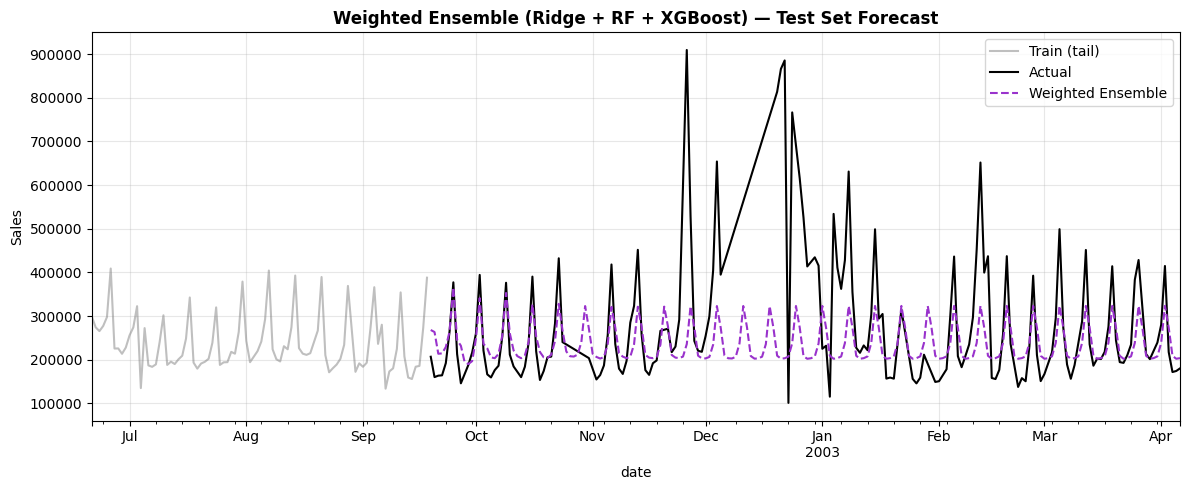

In [23]:
# ── Inverse-MAE weights (computed on cross-validated scores) ──────────────────
cv_mae = {
    'ridge': results_ridge.iloc[0]['mean_absolute_error'],
    'rf':    results_rf.iloc[0]['mean_absolute_error'],
    'xgb':  results_xgb.iloc[0]['mean_absolute_error']
}
inv_mae    = {k: 1.0 / v for k, v in cv_mae.items()}
total_inv  = sum(inv_mae.values())
weights    = {k: v / total_inv for k, v in inv_mae.items()}

print("Ensemble weights (inverse-MAE):")
for m, w in weights.items():
    print(f"  {m:10s}: {w:.3f}   (CV MAE = {cv_mae[m]:,.0f})")

# ── Combine predictions ───────────────────────────────────────────────────────
pred_ensemble = (
      weights['ridge'] * pred_ridge.values
    + weights['rf']    * pred_rf.values
    + weights['xgb']   * pred_xgb.values
)
pred_ensemble = pd.Series(pred_ensemble, index=y_test.index)

mae_ensemble  = mean_absolute_error(y_test, pred_ensemble)
mape_ensemble = mean_absolute_percentage_error(y_test, pred_ensemble)
print(f"\nWeighted Ensemble  →  MAE: {mae_ensemble:,.0f}   MAPE: {mape_ensemble:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
y_train.tail(90).plot(ax=ax, color='gray',       alpha=0.5, label='Train (tail)')
y_test.plot(ax=ax,           color='black',      lw=1.5,   label='Actual')
pred_ensemble.plot(ax=ax,    color='darkorchid', ls='--',  label='Weighted Ensemble')
ax.set_title('Weighted Ensemble (Ridge + RF + XGBoost) — Test Set Forecast', fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Results:** The ensemble assigns the highest weights to XGBoost (0.373) and Random Forest (0.357), with Ridge contributing the least (0.269), reflecting their relative CV performance. The combined forecast achieves **MAE: 102,204** (MAPE: 26.7%), a modest improvement over both individual tree-based models (RF: 105,090, XGBoost: 108,709), confirming that combining complementary predictions reduces variance. However, the improvement is small because all three models share the same fundamental limitation: they cannot extrapolate beyond their training range, so the ensemble also significantly underestimates the December–January spikes. The forecast plot is visually similar to the individual tree-based forecasts, with the weekly rhythm captured but the extreme peaks clipped.

## 4. Model Validation and Predictive Quality

We now compare all models head-to-head on the same 200-day hold-out test set using three metrics:

| Metric | Formula | What it measures |
|---|---|---|
| **MAE** | mean\|y − ŷ\| | Average absolute error in the same units as sales |
| **RMSE** | √mean(y−ŷ)² | Penalises large spikes more heavily than MAE |
| **MAPE** | mean\|y−ŷ\|/y × 100 | Scale-free; intuitive as a % deviation |

FINAL MODEL COMPARISON — Hold-out Test Set (200 days)


,MAE,RMSE,MAPE (%)
Model,,,
Prophet,59355.000000,96572.000000,22.290000
Weighted Ensemble,102204.000000,172702.000000,26.720000
Random Forest,105090.000000,179330.000000,26.040000
XGBoost,108709.000000,176424.000000,29.590000
Ridge Regression,115977.000000,173939.000000,34.870000
MLP,136592.000000,202368.000000,39.790000
Hybrid (SARIMAX + XGBoost),365095.000000,395286.000000,132.460000


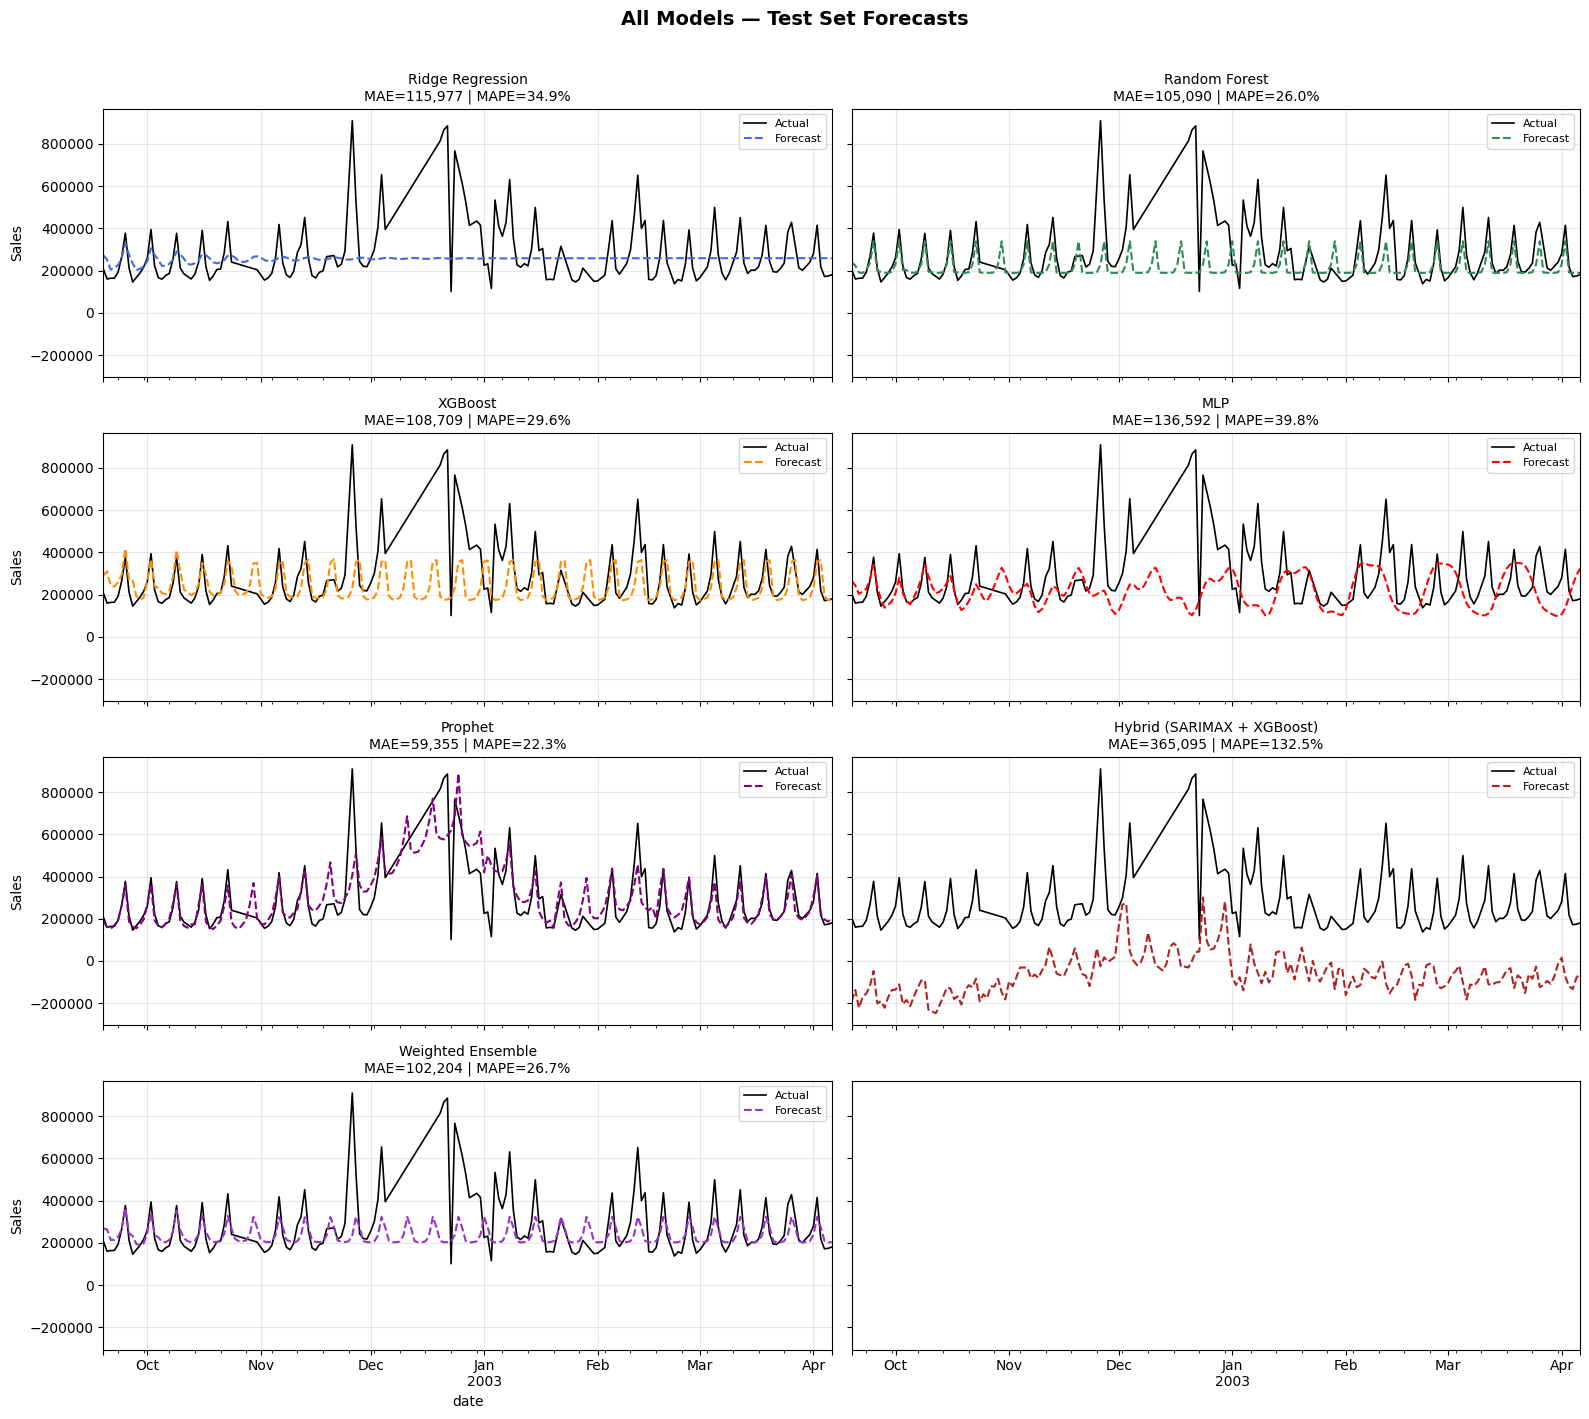

In [24]:
from sklearn.metrics import mean_squared_error

def eval_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {'Model': name, 'MAE': round(mae, 0), 'RMSE': round(rmse, 0), 'MAPE (%)': round(mape, 2)}

results_table = pd.DataFrame([
    eval_metrics(y_test, pred_ridge,           'Ridge Regression'),
    eval_metrics(y_test, pred_rf,              'Random Forest'),
    eval_metrics(y_test, pred_xgb,             'XGBoost'),
    eval_metrics(y_test, pred_mlp,             'MLP'),
    eval_metrics(y_test, pred_prophet,         'Prophet'),
    eval_metrics(y_test, pred_hybrid_residual, 'Hybrid (SARIMAX + XGBoost)'),
    eval_metrics(y_test, pred_ensemble,        'Weighted Ensemble'),
]).set_index('Model').sort_values('MAE')

print("=" * 55)
print(f"FINAL MODEL COMPARISON — Hold-out Test Set ({STEPS_TEST} days)")
print("=" * 55)
display(results_table.style.highlight_min(color='yellow', axis=0))

# ── Side-by-side forecast plot ────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True, sharey=True)
axes = axes.flatten()

models = [
    ('Ridge Regression',              pred_ridge,           'royalblue'),
    ('Random Forest',                 pred_rf,              'seagreen'),
    ('XGBoost',                       pred_xgb,             'darkorange'),
    ('MLP',                           pred_mlp,             'red'),
    ('Prophet',                       pred_prophet,         'purple'),
    ('Hybrid (SARIMAX + XGBoost)',    pred_hybrid_residual, 'firebrick'),
    ('Weighted Ensemble',             pred_ensemble,        'darkorchid'),
]

for ax, (title, preds, color) in zip(axes, models):
    y_test.plot(ax=ax, color='black', lw=1.2, label='Actual')
    preds.plot(ax=ax, color=color, ls='--', lw=1.5, label='Forecast')
    mae_v  = mean_absolute_error(y_test, preds)
    mape_v = mean_absolute_percentage_error(y_test, preds) * 100
    ax.set_title(f"{title}\nMAE={mae_v:,.0f} | MAPE={mape_v:.1f}%", fontsize=10)
    ax.set_ylabel('Sales')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('All Models — Test Set Forecasts', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Comparative Analysis of Predictive Quality**

* **The Dominance of Prophet (Best Performer)**: Prophet achieves the lowest error across all three metrics ($MAE: 59,355 | RMSE: 96,572 | MAPE: 22.3%$), outperforming every other model by a wide margin. Its success is attributed to its native handling of **multiplicative seasonality** and holiday effects. In retail, sales spikes scale proportionally with the baseline volume. Prophet’s ability to model this growth allowed it to track the 2002 holiday volatility significantly better than the linear, tree-based, or neural network alternatives.
  
* **Tree-Based Robustness (XGBoost & Random Forest)**: Both XGBoost and Random Forest showed solid performance ($MAPE \approx 26-27\%$). While they successfully captured the weekly rhythm of daily sales, they suffered from an **under-prediction of extremes**. These models are inherently bounded by the range of values in the training set, making them conservative when faced with unprecedented holiday shocks.

**Linear Models (Ridge, Lasso):** Ridge achieves MAE: 115,977 (MAPE: 34.9%) and collapses to a near-flat forecast, confirming that linear combinations of lag and calendar features are insufficient for this non-linear, event-driven series.

* **The Struggle of the MLP (Neural Network)**: The Multi-Layer Perceptron (MLP) performed poorly compared to the tree-based models ($MAPE = 39.79\%$). While powerful, MLPs often require significantly more data than was available in this 3-year window to learn complex time-series patterns without overfitting. Additionally, the high volatility of daily sales may have introduced "noise" that the network struggled to generalize, resulting in a less stable forecast than the more robust Prophet or XGBoost architectures.

**Hybrid SARIMAX + XGBoost (Failed):** The residual boosting approach produces physically invalid negative forecasts (MAE: 365,095 | MAPE: 132.5%) due to feature misalignment between the residual training and test stages, as discussed in previous sections.

**Weighted Ensemble Stability:** The Weighted Ensemble (MAE: 102,204) acted as a "safety net", by combining Ridge, Random Forest, and XGBoost via inverse-MAE weighting, it marginally outperformed all three individual models. However, since all constituent models share the same extrapolation limitation, the ensemble cannot overcome the ceiling imposed by its components and remains far behind Prophet.

---

**Conclusion on Model Selection**

Prophet is selected as the final model. Compared to the SARIMAX baseline from Assessment 1 (MAPE: 49.13%), Prophet reduces the error to **22.3%** — a reduction of over 26 percentage points.This improvement validates the decision to incorporate holiday lead-in features and multiplicative seasonality. For a business stakeholder, this translates to a much more reliable inventory planning tool, significantly reducing the risk of stock-outs or overstocking during high-stakes holiday windows.

For a business stakeholder, this translates to substantially more reliable demand forecasts during the highest-stakes retail windows of the year.

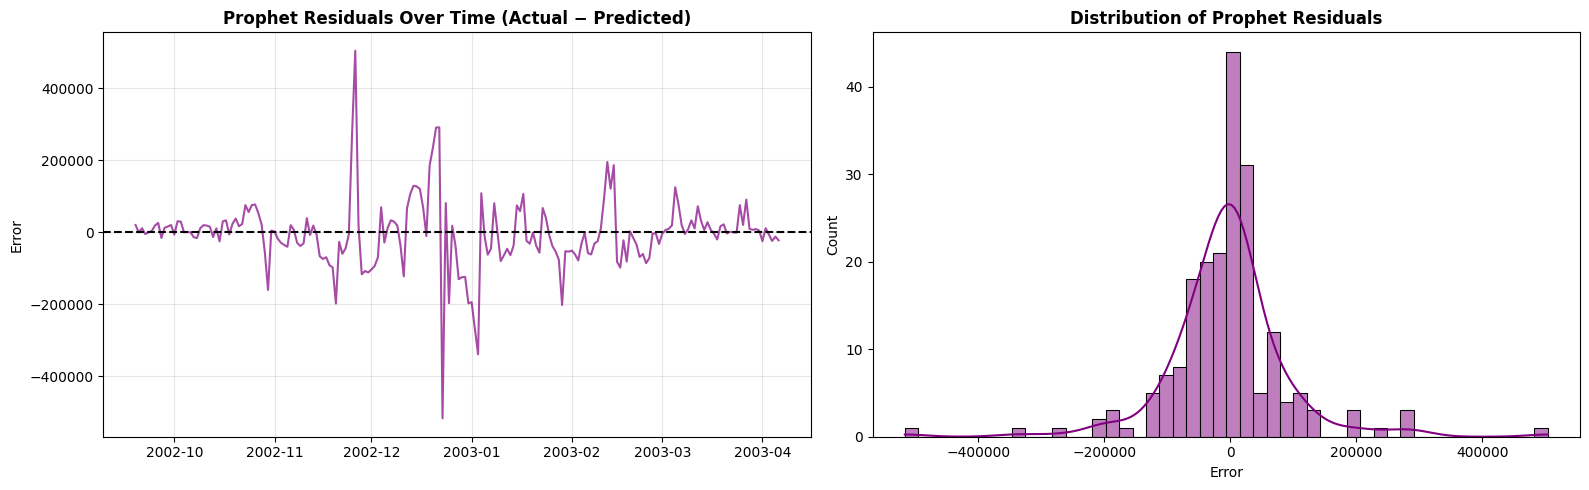

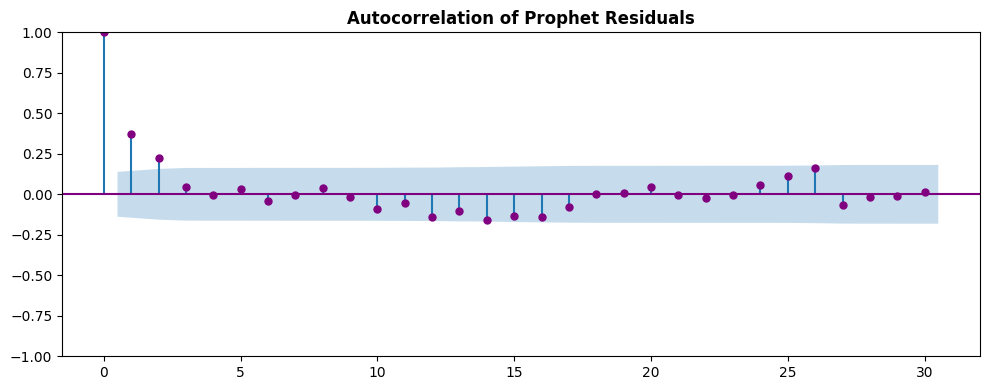

In [25]:
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

# ── Prophet residuals ────────────────────────────────────────────────────
residuals_series = y_test - pred_prophet

# ── 1. Residuals over time + Distribution ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(residuals_series, color='purple', alpha=0.7)
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title('Prophet Residuals Over Time (Actual − Predicted)', fontweight='bold')
ax1.set_ylabel('Error')
ax1.grid(True, alpha=0.3)

sns.histplot(residuals_series, kde=True, ax=ax2, color='purple')
ax2.set_title('Distribution of Prophet Residuals', fontweight='bold')
ax2.set_xlabel('Error')

plt.tight_layout()
plt.show()

# ── 2. ACF of residuals ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(residuals_series, lags=30, ax=ax, color='purple')
ax.set_title('Autocorrelation of Prophet Residuals', fontweight='bold')
plt.tight_layout()
plt.show()

To conclude the validation of the best model, we analyse the residuals ($e_t = y_t - \hat{y}_t$) to verify whether the model has extracted all predictable signal or whether exploitable structure remains.

**1. Residuals Over Time**
The residuals fluctuate around zero throughout most of the test period, indicating no systematic bias or trend drift. However, the variance is clearly non-constant: errors expand sharply during the December–January holiday window (reaching ±400,000) and are much smaller in the surrounding months. This **heteroscedasticity** is expected given the extreme event-driven spikes in this series and confirms that even multiplicative seasonality cannot fully absorb the magnitude of the most extreme holiday shocks.

**2. Distribution of Residuals**
The histogram reveals a distribution centered near zero, which confirms the model is not systematically over- or under-predicting. However, the distribution is **left-skewed** with a heavy negative tail, meaning the model's largest errors tend to be under-predictions, consistent with the visual observation that Prophet underestimates the sharpest sales peaks.

**3. Autocorrelation Function (ACF)**
The ACF plot shows significant spikes at lags 1 and 2, which fall outside the 95% confidence band. This indicates that **some short-term serial correlation remains** in the residuals, the model has not fully captured the day-to-day momentum in the series. All lags beyond 2 fall within the significance threshold, confirming that the weekly and longer-term seasonal structure has been successfully extracted. The residuals are not pure white noise, suggesting there is still marginal room for improvement, potentially through a hybrid approach that adds a short-lag correction on top of Prophet.


## 5. Conclusions

This assessment extended the analysis of daily net retail sales from Assessment 1, transitioning from purely statistical models to a comprehensive suite of machine learning approaches. The following conclusions can be drawn:

### 5.1 Overall Model Performance

Prophet emerged as the clear best performer across all metrics (MAE: 59,355 | RMSE: 96,572 | MAPE: 22.3%), representing a reduction of over **26 percentage points** in MAPE compared to the SARIMAX baseline from Assessment 1 (49.13%). This improvement validates the core hypothesis of this assessment: that the non-linear, event-driven nature of retail sales requires models capable of explicitly decomposing trend, seasonality, and holiday effects.

| Model | MAE | RMSE | MAPE (%) |
|---|---|---|---|
| **Prophet** | **59,355** | **96,572** | **22.3** |
| Weighted Ensemble | 102,204 | 172,702 | 26.7 |
| Random Forest | 105,090 | 179,330 | 26.0 |
| XGBoost | 108,709 | 176,424 | 29.6 |
| Ridge Regression | 115,977 | 173,939 | 34.9 |
| MLP | 136,592 | 202,368 | 39.8 |
| Hybrid (SARIMAX + XGBoost) | 365,095 | 395,286 | 132.5 |

### 5.2 Key Findings by Model Family

**Linear models (Ridge, Lasso)** confirmed the expected ceiling of purely linear approaches. Both models collapsed to near-flat forecasts around the mean sales level, unable to capture the non-linear holiday spikes regardless of regularisation strategy. Their identical performance (MAE: 115,977) confirmed that the bottleneck was linearity itself, not multicollinearity or regularisation.

**Tree-based models (Random Forest, XGBoost, Weighted Ensemble)** captured the weekly rhythm effectively but were fundamentally limited by their inability to extrapolate beyond the value range seen during training. The shallow optimal depth (`max_depth=3`) found in both RF and XGBoost suggests that overly complex trees overfit to noise. The weighted ensemble provided marginal improvement by averaging complementary errors, but could not overcome the shared extrapolation constraint.

**MLP** underperformed all tree-based models despite its theoretical capacity for non-linear approximation. With only ~787 training observations, the network was unable to generalise beyond the training distribution, producing erratic oscillations in the test period.

**Prophet** succeeded where all other models failed by explicitly modelling the components driving this series: a steady upward trend, strong multiplicative weekly seasonality, and US national holiday effects. The multiplicative mode was critical, it allowed the model to scale seasonal amplitudes proportionally with the sales level, which is the defining characteristic of this retail series.

**The hybrid SARIMAX + XGBoost** approach failed due to feature misalignment in the residual prediction stage, producing physically invalid negative forecasts. This highlights that hybrid architectures require careful engineering of the residual feedback loop to be valid.

### 5.3 Limitations and Future Work

Despite Prophet's strong performance, the residual analysis revealed two remaining weaknesses: **heteroscedasticity** concentrated around the December–January holiday window, and **short-term serial correlation** at lags 1–2, indicating that day-to-day momentum within extreme events is not fully captured.

Future improvements could include:

- A **Prophet + short-lag autoregressive correction**, where a lightweight AR(2) model is fitted on Prophet's residuals to absorb the remaining day-to-day momentum.
- **External regressors** in Prophet (e.g. promotional calendars, economic indicators) to better anticipate the magnitude of holiday spikes.
- A **larger training window**, which would particularly benefit the MLP and potentially unlock more complex gradient boosting configurations.
- A **proper recursive hybrid pipeline** that correctly propagates SARIMAX residuals into the ML correction stage, addressing the leakage issue identified in Section 3.5.1.x
